## 1. What this notebook computes

This notebook builds, from zero, the tools that every later notebook uses to
handle lists of numbers: vectors, matrices, permutations and determinants. It

- multiplies a matrix with a vector and two matrices with each other in three
  ways (with loops, with the summation convention, with numpy's operator `@`)
  and shows with heat maps that $AB$ and $BA$ are in general different;
- lists the permutations (re-orderings) of 3 and of 4 objects, counts their
  inversions and gives each its sign $+1$ or $-1$;
- computes determinants with the Leibniz formula, written by hand in Python,
  and compares the results with the programs numpy and sympy;
- checks six rules of determinants, and draws what a $2 \times 2$ determinant
  means: the signed area of a parallelogram;
- explains with a plot why computers do not use the Leibniz formula for big
  matrices;
- reads the eight real $16 \times 16$ gamma matrices of the author's theory from
  the Revision record and checks that each one is a *signed permutation matrix*
  whose determinant is 1;
- reads the author's metric from the Revision record and proves with sympy that
  its determinant is $\cos^2 z$ with $z = 6 H x_8$, whatever the value of $a_4$.

Every check prints a line that starts with PASS; where a check repeats a result
of the Revision record, a second line names the record file and its check.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 01a (Matrices, permutations and determinants) is the file
`Revision/textbook/notebooks/01a_matrices_determinants.ipynb` of the repository
Dirac_claude. It multiplies matrices in three ways (with loops, with the summation
convention through numpy einsum, and with the operator @) and shows with heat maps that
the order of the factors matters, lists the permutations of up to four objects with their
signs, computes determinants with the Leibniz formula and compares them with numpy and
sympy, checks the rules of determinants and draws their meaning as a signed area, reads
the real 16 by 16 gamma matrices and the frame metric of the author's coordinates x1 to
x8 from the Revision record and checks that every gamma matrix is a signed permutation
matrix with determinant 1, and proves with sympy that the determinant of the author's
metric is the square of cos(6 H x8) for every value of a4. It needs a computer with
Windows 11, macOS or Linux, an internet connection for the installation, the program Git,
and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 01a_matrices_determinants.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 01a_matrices_determinants.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
01a_matrices_determinants.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/01a.captions.json`
- `Revision/textbook/figures/01a_1_matrix_product.png`
- `Revision/textbook/figures/01a_2_permutation_matrices.png`
- `Revision/textbook/figures/01a_3_area_and_determinant.png`
- `Revision/textbook/figures/01a_4_determinant_cost.png`
- `Revision/textbook/figures/01a_5_gamma_matrices.png`
- `Revision/textbook/figures/01a_6_metric_and_determinant.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all 6 figure files of this notebook exist
    ALL 30 CHECKS PASSED (notebook 01a)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/01a_matrices_determinants.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 01a_matrices_determinants.ipynb
      python -m nbconvert --execute --inplace 01a_matrices_determinants.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below Revision/algebra or Revision/gkd_lovelock: the
  notebook reads two Revision records of the repository; your copy of the repository is
  incomplete. Download it again with git clone and open the notebook inside the new copy.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 01a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 01a (Matrices, permutations and determinants) is the file
# Revision/textbook/notebooks/01a_matrices_determinants.ipynb of the repository
# Dirac_claude. It multiplies matrices in three ways (with loops, with the summation
# convention through numpy einsum, and with the operator @) and shows with heat maps that
# the order of the factors matters, lists the permutations of up to four objects with
# their signs, computes determinants with the Leibniz formula and compares them with
# numpy and sympy, checks the rules of determinants and draws their meaning as a signed
# area, reads the real 16 by 16 gamma matrices and the frame metric of the author's
# coordinates x1 to x8 from the Revision record and checks that every gamma matrix is a
# signed permutation matrix with determinant 1, and proves with sympy that the
# determinant of the author's metric is the square of cos(6 H x8) for every value of a4.
# It needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 01a_matrices_determinants.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 01a_matrices_determinants.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 01a_matrices_determinants.ipynb (in the same folder, without running the cells again)
# to read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/01a.captions.json
# - Revision/textbook/figures/01a_1_matrix_product.png
# - Revision/textbook/figures/01a_2_permutation_matrices.png
# - Revision/textbook/figures/01a_3_area_and_determinant.png
# - Revision/textbook/figures/01a_4_determinant_cost.png
# - Revision/textbook/figures/01a_5_gamma_matrices.png
# - Revision/textbook/figures/01a_6_metric_and_determinant.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all 6 figure files of this notebook exist
#     ALL 30 CHECKS PASSED (notebook 01a)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/01a_matrices_determinants.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 01a_matrices_determinants.ipynb
#     python -m nbconvert --execute --inplace 01a_matrices_determinants.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below Revision/algebra or Revision/gkd_lovelock: the
#   notebook reads two Revision records of the repository; your copy of the repository is
#   incomplete. Download it again with git clone and open the notebook inside the new
#   copy.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "01a"  # this notebook: chapter 01, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 01a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Vector**: an ordered list of numbers, such as $v = (1, 2, 0)$. The numbers
  are its **components**; $v$ has 3 components.
- **Matrix**: a rectangular table of numbers with rows (across) and columns
  (down). $A_{ij}$ is the **entry** in row $i$ and column $j$. A matrix with $m$
  rows and $n$ columns is an $m \times n$ matrix; it is **square** if $m = n$.
- **Index**: a letter such as $i$, $j$ or $k$ that numbers the components of a
  vector or the rows and columns of a matrix. In mathematics rows and columns
  are numbered $1, 2, 3, \dots$; Python numbers them $0, 1, 2, \dots$, so the
  entry $A_{11}$ (row 1, column 1) is `A[0, 0]` in Python.
- **Matrix product**: $(AB)_{ik} = \sum_j A_{ij} B_{jk}$: entry $(i, k)$ of $AB$
  is row $i$ of $A$ times column $k$ of $B$, entry by entry, added up.
- **Summation convention**: an index that appears twice in one product is summed
  over all its values without writing $\sum$; so $A_{ij} B_{jk}$ means
  $\sum_j A_{ij} B_{jk}$. A summed index is a **dummy** index (its name does not
  matter); an index that is not summed is a **free** index. In the physics of the
  course one of the two equal indices is written up and one down, as in
  $v^\mu w_\mu = \sum_\mu v^\mu w_\mu$; for the entries of plain tables of
  numbers, as in this notebook, both are written down.
- **einsum**: numpy's function that evaluates a product written with the
  summation convention, for example `np.einsum("ij,jk->ik", A, B)`.
- **Identity matrix** $I$: the square matrix with 1 on the diagonal and 0
  elsewhere. Its entries are the **Kronecker delta** $\delta_{ij}$, which is 1
  when $i = j$ and 0 otherwise.
- **Transpose** $A^T$: the matrix with rows and columns exchanged,
  $(A^T)_{ij} = A_{ji}$.
- **Permutation**: a re-ordering of the numbers $0, 1, \dots, n-1$ (or of any $n$
  different objects). There are $n! = 1 \cdot 2 \cdots n$ of them.
- **Inversion**: a pair of places in a permutation whose two entries stand in the
  wrong order (the larger one first).
- **Sign** of a permutation: $+1$ if it has an even number of inversions (an
  **even** permutation), $-1$ if odd.
- **Permutation matrix**: the matrix with exactly one 1 in every row and every
  column and 0 elsewhere; row $i$ has its 1 in column $\sigma(i)$ for a
  permutation $\sigma$. A **signed permutation matrix** may have $-1$ instead of
  $1$ in some of these places.
- **Determinant** $\det A$ of a square matrix (Leibniz formula):
  $\det A = \sum_\sigma \mathrm{sign}(\sigma) A_{1\sigma(1)} A_{2\sigma(2)}
  \cdots A_{n\sigma(n)}$, the sum over all $n!$ permutations $\sigma$.
- **Heat map**: a picture of a matrix in which every entry is a coloured square
  (here red for positive, white for zero, blue for negative entries).
- **Floating-point number**: the way a computer stores a real number, with about
  16 significant digits, so results can be off in the last digits. **Exact**
  arithmetic (sympy) keeps whole numbers, fractions and symbols without rounding.
- **Metric** $g$: the table of numbers that turns small coordinate steps
  $dx_1, \dots, dx_8$ into a squared length,
  $ds^2 = g_{11} dx_1^2 + \dots + g_{88} dx_8^2$ for a diagonal metric; here it is
  a diagonal $8 \times 8$ matrix (only the diagonal entries $g_{11}, \dots,
  g_{88}$ are not zero), and a negative entry marks a time-like direction.
- **Revision record**: the files of the folder Revision of the repository, in
  which every result of the author's theory is computed and checked.

## 4. The physical and mathematical situation

The theory of this course works with matrices everywhere. Its spacetime has
eight coordinates, which the author calls $x_1, \dots, x_8$: $x_1, x_2, x_3$ are
ordinary space, $x_4$ is the time, $x_5, x_6, x_7$ are three extra times whose
lengths deflate exponentially as $a_4$ grows, and $x_8$ is a hidden space
direction. The author's metric is the diagonal matrix

$$g = \mathrm{diag}\big(e^{2a_4} s, e^{2a_4} s, e^{2a_4} s, -1,
-e^{-2a_4} s, -e^{-2a_4} s, -e^{-2a_4} s, \cot^2 z\big),\quad
s = \sin^{1/3} z,\ z = 6 H x_8,$$

with $0 < z < \pi/2$, a positive constant $H$ and a function $a_4(x_4)$ of the
time. The simpler *frame metric*
$\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$ keeps only the signs: $+1$
for the space-like directions $x_1, x_2, x_3, x_8$ and $-1$ for the time-like
directions $x_4, x_5, x_6, x_7$. The fields of the theory have 16 components, and
the eight *gamma matrices* that act on them are real $16 \times 16$ matrices.

The determinant is the one number that tells whether a square matrix can be
undone (inverted): it can exactly when $\det A \neq 0$. For a diagonal matrix
only one term of the Leibniz formula survives (all others contain an entry off
the diagonal, which is 0), so the determinant is the product of the diagonal
entries. For the author's metric this product is

$$\det g = (e^{2a_4} s)^3 \cdot (-1) \cdot (-e^{-2a_4} s)^3 \cdot \cot^2 z
= e^{6a_4} e^{-6a_4} s^6 \cot^2 z = \sin^2 z \, \frac{\cos^2 z}{\sin^2 z}
= \cos^2 z,$$

because $(-1) \cdot (-1)^3 = +1$, $e^{6a_4} e^{-6a_4} = e^0 = 1$,
$s^6 = (\sin^{1/3} z)^6 = \sin^2 z$ and $\cot z = \cos z / \sin z$. The growth
$e^{6a_4}$ of the three space directions is cancelled exactly by the shrinking
$e^{-6a_4}$ of the three extra times. The last part of the notebook checks this
with sympy, starting from the metric as it is stored in the Revision record.

## 5. Vectors and matrices in Python

The next cell loads the packages, makes two vectors $v = (1, 2, 0)$ and
$w = (0, 1, 1)$ as numpy arrays, adds them, multiplies $v$ by 3, and computes
the **dot product** $v \cdot w = \sum_i v_i w_i = 1 \cdot 0 + 2 \cdot 1 + 0
\cdot 1 = 2$ twice: once as a written-out sum and once with numpy's `@`.
`tolist()` turns an array into a plain Python list for printing.

In [2]:
import itertools  # all orderings (permutations) of a list
import math  # factorials

import numpy as np  # arrays of numbers: vectors and matrices
import sympy as sp  # exact arithmetic with whole numbers, fractions and symbols

v = np.array([1, 2, 0])  # a vector with 3 components
w = np.array([0, 1, 1])
say(f"v = {v.tolist()}, w = {w.tolist()}")
say(f"v + w = {(v + w).tolist()}, 3 v = {(3 * v).tolist()}")
# The dot product as a sum over the index i = 0, 1, 2 (Python counts from 0):
dot_by_hand = sum(int(v[i]) * int(w[i]) for i in range(3))
say(f"v . w by the sum = {dot_by_hand}, with numpy's @ = {int(v @ w)}")
check(dot_by_hand == int(v @ w) == 2, "the dot product of v and w is 2")

v = [1, 2, 0], w = [0, 1, 1]
v + w = [1, 3, 1], 3 v = [3, 6, 0]
v . w by the sum = 2, with numpy's @ = 2
PASS the dot product of v and w is 2


The next cell makes the $3 \times 3$ matrix $A$ with rows $(1, 2, 0)$,
$(0, 1, 1)$ and $(1, 3, 1)$ and multiplies it with the vector $v$ by the rule
$(Av)_i = \sum_j A_{ij} v_j$, written as a loop, and with numpy's `A @ v`. Row 1
gives $1 \cdot 1 + 2 \cdot 2 + 0 \cdot 0 = 5$, row 2 gives
$0 + 2 + 0 = 2$, row 3 gives $1 + 6 + 0 = 7$.

In [3]:
A = np.array([[1, 2, 0],
              [0, 1, 1],
              [1, 3, 1]])  # three rows, each a list of three entries
say(f"A has {A.shape[0]} rows and {A.shape[1]} columns")
# Python counts rows and columns from 0: A[1, 2] is row 2, column 3 of A.
say(f"the entry in row 2, column 3 of A is A[1, 2] = {A[1, 2]}")
# (A v)_i = sum over j of A_ij v_j, one number for each row i:
Av_by_hand = [sum(int(A[i, j]) * int(v[j]) for j in range(3)) for i in range(3)]
say(f"A v by the sum = {Av_by_hand}, with numpy = {(A @ v).tolist()}")
check(Av_by_hand == (A @ v).tolist() == [5, 2, 7],
      "A v computed with the sum rule is (5, 2, 7), the same as numpy's A @ v")

A has 3 rows and 3 columns
the entry in row 2, column 3 of A is A[1, 2] = 1
A v by the sum = [5, 2, 7], with numpy = [5, 2, 7]
PASS A v computed with the sum rule is (5, 2, 7), the same as numpy's A @ v


## 6. The matrix product, three ways

The next cell multiplies $A$ with a second matrix $B$ in three ways and checks
that they agree:

1. three nested loops that add $A_{ij} B_{jk}$ over the dummy index $j$ for every
   pair of free indices $(i, k)$;
2. `np.einsum("ij,jk->ik", A, B)`: the text `"ij,jk->ik"` is the summation
   convention itself. It says: the first factor has the indices $i, j$, the
   second $j, k$; the index $j$ appears twice, so it is summed; the result has
   the indices $i, k$;
3. numpy's operator `A @ B`.

Then it computes $BA$ and checks that it differs from $AB$: the order of the
factors of a matrix product matters. It also checks the transpose rule
$(AB)^T = B^T A^T$ (`.T` is numpy's transpose) and that the trace (the sum of
the diagonal entries, `np.trace`) of $AB$ and of $BA$ is the same.

In [4]:
B = np.array([[0, 1, 0],
              [1, 0, 2],
              [0, 1, 1]])
n = 3
AB_loops = np.zeros((n, n), dtype=int)  # a 3 x 3 matrix of zeros to fill in
for i in range(n):  # the row of the product (a free index)
    for k in range(n):  # the column of the product (a free index)
        for j in range(n):  # the summed (dummy) index
            AB_loops[i, k] += A[i, j] * B[j, k]
AB_einsum = np.einsum("ij,jk->ik", A, B)  # j appears twice: it is summed
AB = A @ B
BA = B @ A
say(f"A B = {AB.tolist()}")
say(f"B A = {BA.tolist()}")
check((AB_loops == AB).all() and (AB_einsum == AB).all(),
      "loops, einsum and @ give the same product A B")
check(not (AB == BA).all(), "A B is not equal to B A: the order matters")
check(((A @ B).T == B.T @ A.T).all(), "the transpose rule (A B)^T = B^T A^T")
check(np.trace(AB) == np.trace(BA), "A B and B A have the same trace")

A B = [[2, 1, 4], [1, 1, 3], [3, 2, 7]]
B A = [[0, 1, 1], [3, 8, 2], [1, 4, 2]]
PASS loops, einsum and @ give the same product A B
PASS A B is not equal to B A: the order matters
PASS the transpose rule (A B)^T = B^T A^T
PASS A B and B A have the same trace


The next cell defines a small drawing helper, `heat_map`, used for every picture
of a matrix in this notebook, and draws $A$, $B$, $AB$ and $BA$. Each entry is a
coloured square (red positive, white zero, blue negative) with its value written
in it. `plt.subplots(1, 4)` makes a figure with 4 drawing areas (*axes*) side by
side; `save_figure` saves the picture, shows it below the cell and records its
caption.

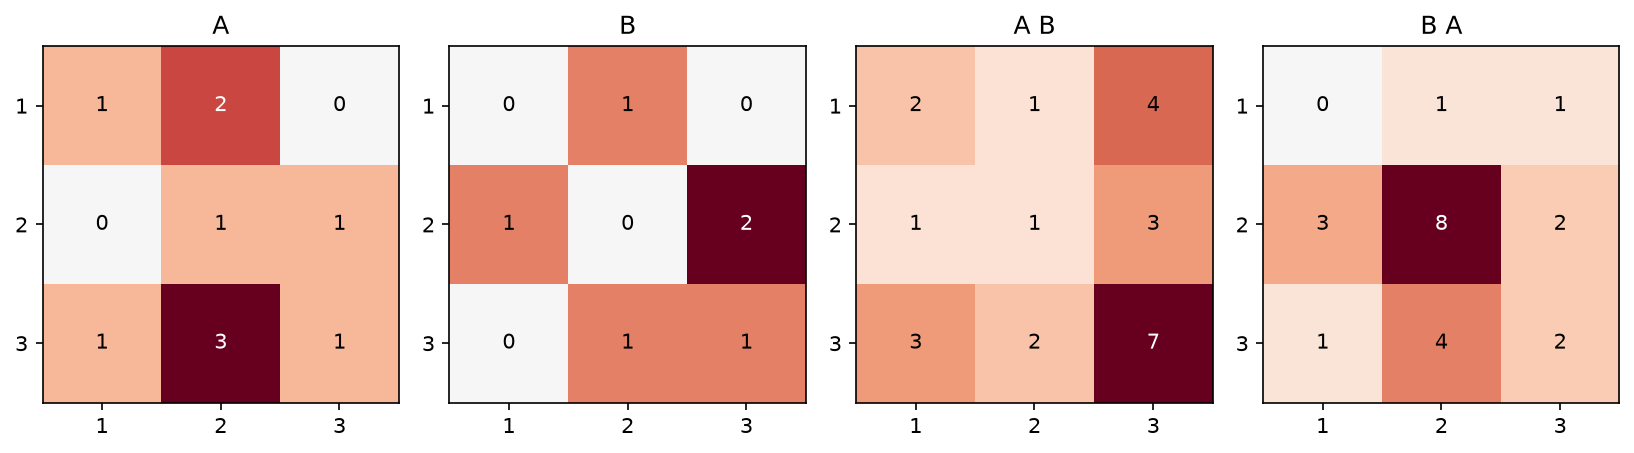

Figure 01a.1 saved as Revision/textbook/figures/01a_1_matrix_product.png


In [5]:
def heat_map(ax, matrix, title, labels=None, annotate=True, digits=0,
             skip_zeros=False):
    """Draw matrix on the axes ax: every entry a coloured square, red for
    positive, white for zero, blue for negative entries; when annotate is True
    the value is written in its square with the given number of digits (not
    for the zero entries when skip_zeros is True)."""
    m = np.asarray(matrix, dtype=float)
    limit = max(1.0, float(np.abs(m).max()))  # colours run from -limit to +limit
    image = ax.imshow(m, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.grid(False)  # no grid lines across the coloured squares
    if labels is None:  # number rows and columns 1, 2, 3, ... as in mathematics
        labels = [str(k + 1) for k in range(m.shape[0])]
    ax.set_xticks(range(m.shape[1]), labels[:m.shape[1]])
    ax.set_yticks(range(m.shape[0]), labels[:m.shape[0]])
    if annotate:
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                if skip_zeros and m[i, j] == 0:
                    continue
                # white writing on dark squares, black writing on light ones
                ink = "white" if abs(m[i, j]) > 0.6 * limit else "black"
                ax.text(j, i, f"{m[i, j]:.{digits}f}", ha="center", va="center",
                        color=ink)
    return image


fig, axes = plt.subplots(1, 4, figsize=(11.0, 3.2))
for ax, matrix, title in zip(axes, [A, B, AB, BA], ["A", "B", "A B", "B A"]):
    heat_map(ax, matrix, title)
fig.tight_layout()
save_figure(fig, "matrix_product",
            "Heat maps of the $3 \\times 3$ matrices $A$, $B$ and of their products "
            "$AB$ and $BA$; rows are numbered down and columns across from 1 to 3, "
            "and every square shows its entry, red for positive and white for zero "
            "entries. The two products have different entries, for example 4 and 1 "
            "in row 1, column 3: the order of the factors of a matrix product "
            "matters.")

## 7. Permutations and their signs

A permutation of $0, 1, \dots, n-1$ is the same list in another order. An
**inversion** is a pair of places $i < j$ where the entry at place $i$ is larger
than the entry at place $j$. The sign is $(-1)^{\text{number of inversions}}$.

The next cell defines the functions `inversions` and `sign` and prints the six
permutations of $0, 1, 2$ (Python's `itertools.permutations` lists them) with
their inversions and signs. For example $(1, 2, 0)$ has the inversions
$(1, 0)$ and $(2, 0)$, two of them, so its sign is $+1$; $(0, 2, 1)$ has one
inversion, $(2, 1)$, so its sign is $-1$.

In [6]:
def inversions(order):
    """The number of pairs of places i < j whose entries stand in the wrong order."""
    return sum(1 for i in range(len(order)) for j in range(i + 1, len(order))
               if order[i] > order[j])


def sign(order):
    """+1 for an even number of inversions, -1 for an odd number."""
    return 1 if inversions(order) % 2 == 0 else -1


for order in itertools.permutations(range(3)):  # all 6 orderings of 0, 1, 2
    say(f"permutation {order}: number of inversions {inversions(order)}, "
        f"sign {sign(order):+d}")
signs_of_three = [sign(order) for order in itertools.permutations(range(3))]
check(signs_of_three.count(1) == 3 and signs_of_three.count(-1) == 3,
      "of the 6 permutations of 3 objects, 3 are even and 3 are odd")

permutation (0, 1, 2): number of inversions 0, sign +1
permutation (0, 2, 1): number of inversions 1, sign -1
permutation (1, 0, 2): number of inversions 1, sign -1
permutation (1, 2, 0): number of inversions 2, sign +1
permutation (2, 0, 1): number of inversions 2, sign +1
permutation (2, 1, 0): number of inversions 3, sign -1
PASS of the 6 permutations of 3 objects, 3 are even and 3 are odd


The next cell checks three facts for every $n$ from 1 to 6:

- there are $n!$ permutations (`math.factorial(n)`);
- for $n \geq 2$ exactly half of them are even;
- exchanging the entries at two places of a permutation always changes its sign
  (checked for every permutation of $n$ objects and every pair of places).

The third fact is the reason why a determinant changes sign when two rows are
exchanged (section 9 of this notebook).

In [7]:
swap_rule_holds = True
for n in range(1, 7):
    orders = list(itertools.permutations(range(n)))
    even = sum(1 for order in orders if sign(order) == 1)
    say(f"n = {n}: n! = {len(orders):3d} permutations; even {even:3d}, "
        f"odd {len(orders) - even:3d}")
    swap_rule_holds &= len(orders) == math.factorial(n)
    swap_rule_holds &= (n == 1 or 2 * even == len(orders))
    for order in orders:
        for i in range(n):
            for j in range(i + 1, n):
                swapped = list(order)
                swapped[i], swapped[j] = swapped[j], swapped[i]  # exchange two
                swap_rule_holds &= sign(swapped) == -sign(order)
check(swap_rule_holds, "n! permutations, half of them even (n >= 2), and every "
      "exchange of two entries flips the sign (n = 1 to 6)")

n = 1: n! =   1 permutations; even   1, odd   0
n = 2: n! =   2 permutations; even   1, odd   1
n = 3: n! =   6 permutations; even   3, odd   3
n = 4: n! =  24 permutations; even  12, odd  12
n = 5: n! = 120 permutations; even  60, odd  60
n = 6: n! = 720 permutations; even 360, odd 360
PASS n! permutations, half of them even (n >= 2), and every exchange of two entries flips
    the sign (n = 1 to 6)


The **permutation matrix** $P_\sigma$ of a permutation $\sigma$ has a 1 in row $i$,
column $\sigma(i)$ and 0 elsewhere. The next cell draws the 24 permutation
matrices of 4 objects, each with the sign of its permutation in the title. Look
at them: the identity (sign $+1$) is the diagonal; exchanging two rows of a
matrix always gives the matrix of a permutation with the opposite sign. The
next section of this notebook proves that $\det P_\sigma = \mathrm{sign}(\sigma)$.

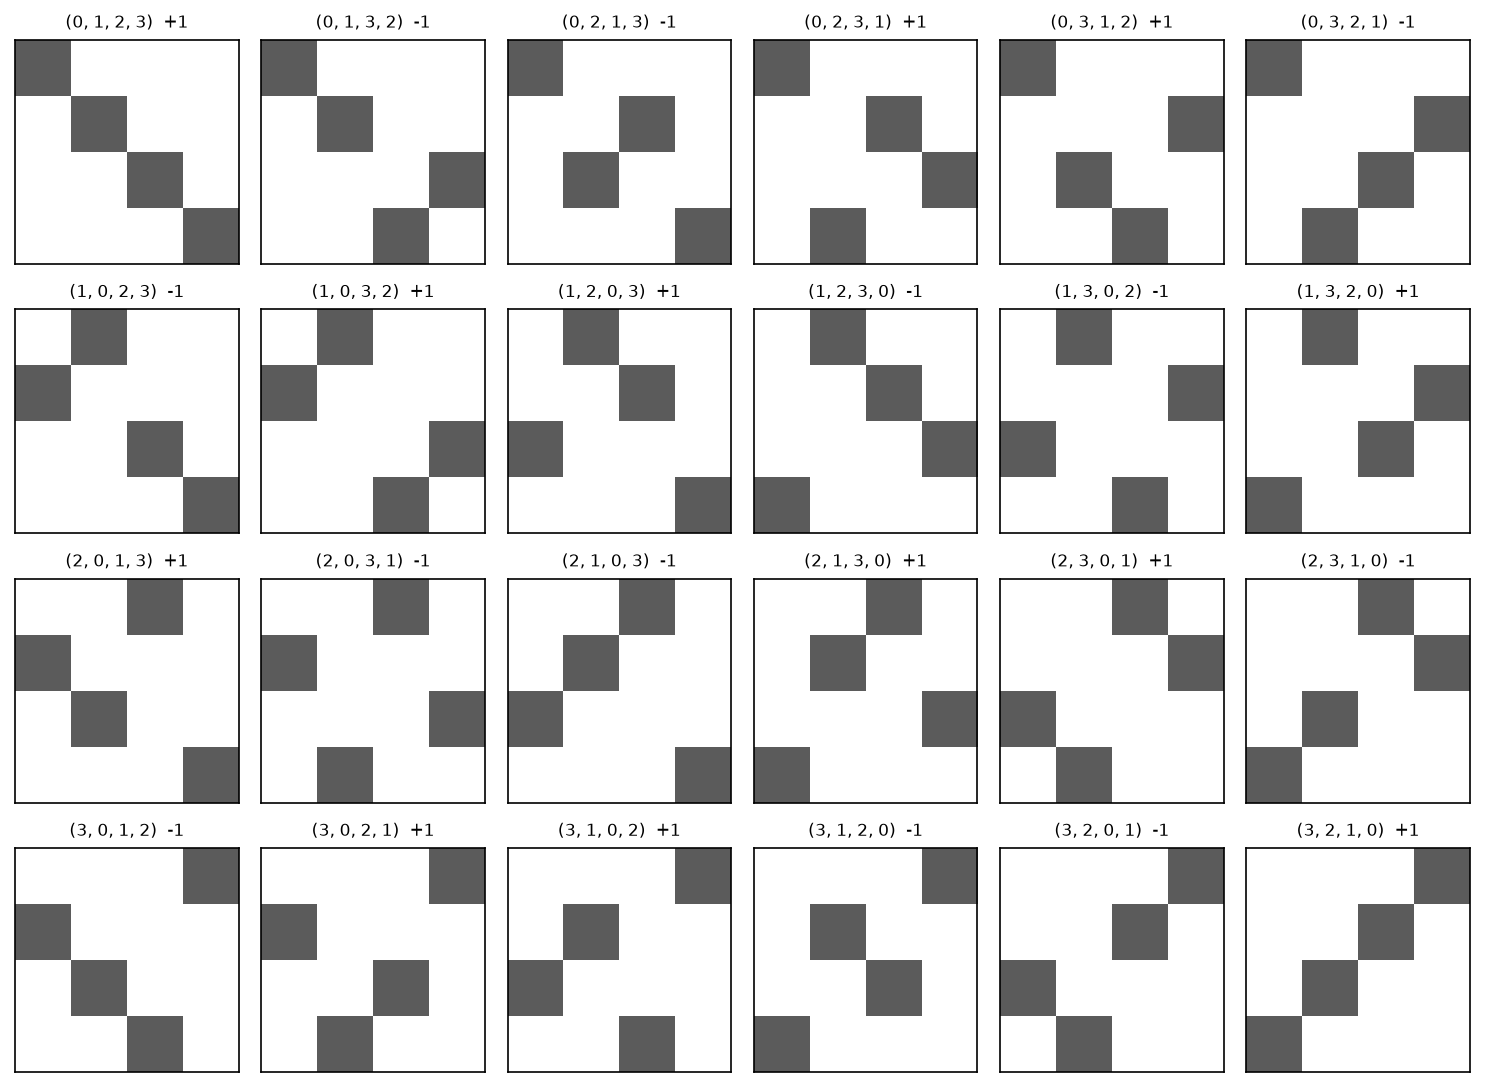

Figure 01a.2 saved as Revision/textbook/figures/01a_2_permutation_matrices.png


In [8]:
def permutation_matrix(order):
    """The matrix with a 1 in row i, column order[i], and 0 elsewhere."""
    P = np.zeros((len(order), len(order)), dtype=int)
    for i, column in enumerate(order):
        P[i, column] = 1
    return P


fig, axes = plt.subplots(4, 6, figsize=(10.0, 7.4))
for ax, order in zip(axes.flat, itertools.permutations(range(4))):
    # Grey squares for the 1s; the title gives the permutation and its sign.
    ax.imshow(permutation_matrix(order), cmap="Greys", vmin=0, vmax=1.4)
    ax.set_title(f"{order}  {sign(order):+d}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
save_figure(fig, "permutation_matrices",
            "The 24 permutation matrices of 4 objects; each small picture is a "
            "$4 \\times 4$ matrix whose dark squares are the entries 1 (all other "
            "entries are 0), and the title gives the permutation, listing for rows "
            "1 to 4 the column of the 1 counted from 0, followed by its sign. "
            "Twelve signs are $+1$ and twelve are $-1$; the first picture is the "
            "identity matrix.")

## 8. The determinant by the Leibniz formula

The Leibniz formula takes, for every permutation $\sigma$, one entry from every
row $i$, namely the one in column $\sigma(i)$, multiplies them, attaches the sign
of $\sigma$, and adds the $n!$ results:

$$\det A = \sum_\sigma \mathrm{sign}(\sigma) A_{1\sigma(1)} \cdots
A_{n\sigma(n)}.$$

For $n = 2$ the two permutations $(1, 2)$ (sign $+1$) and $(2, 1)$ (sign $-1$)
give $\det A = A_{11} A_{22} - A_{12} A_{21}$, the familiar $ad - bc$.

The next cell writes this formula as the Python function `leibniz_det` and
tests it: with sympy symbols for a general $2 \times 2$ matrix (result
$ad - bc$); on the matrix $A$ of section 5 (whose third row is the sum of the
first two, so its determinant must be 0); and on the permutation matrices of 4
objects, whose determinant must be the sign of the permutation (only the term of
$\sigma$ itself is not zero, and it equals $\mathrm{sign}(\sigma) \cdot 1$).

In [9]:
def leibniz_det(M):
    """The determinant of the square matrix M (a list of rows, a numpy array or a
    sympy Matrix) by the Leibniz formula: for every permutation, the sign times
    one entry from every row, row i giving the entry in column order[i]."""
    rows = [list(row) for row in (M.tolist() if hasattr(M, "tolist") else M)]
    total = 0
    for order in itertools.permutations(range(len(rows))):
        term = sign(order)
        for i in range(len(rows)):
            term = term * rows[i][order[i]]
        total = total + term
    return total


a, b, c, d = sp.symbols("a b c d")  # four symbols: letters for any numbers
det_2 = leibniz_det([[a, b], [c, d]])
say(f"det of the 2 x 2 matrix with rows (a, b) and (c, d) = {det_2}")
check(sp.expand(det_2 - (a * d - b * c)) == 0, "Leibniz for 2 x 2: a d - b c")
say(f"det A = {leibniz_det(A)} (row 3 of A is row 1 plus row 2)")
check(leibniz_det(A) == 0, "det A = 0 because the rows of A are dependent")
check(all(leibniz_det(permutation_matrix(order)) == sign(order)
          for order in itertools.permutations(range(4))),
      "the determinant of every permutation matrix of 4 objects is its sign")

det of the 2 x 2 matrix with rows (a, b) and (c, d) = a*d - b*c
PASS Leibniz for 2 x 2: a d - b c
det A = 0 (row 3 of A is row 1 plus row 2)
PASS det A = 0 because the rows of A are dependent
PASS the determinant of every permutation matrix of 4 objects is its sign


The next cell compares three ways of computing a determinant on matrices of
whole numbers between $-5$ and $5$ of sizes $n = 1$ to $7$, made by numpy's
random-number generator with the fixed *seed* 12345 (the same numbers on every
computer and every run):

- `leibniz_det` (exact: Python adds and multiplies whole numbers without
  rounding);
- sympy's `Matrix.det()` (exact, by another method, elimination);
- numpy's `np.linalg.det` (floating point, by elimination; it may be off in the
  last digits, so it only has to agree to one millionth of the size of the
  exact result).

In [10]:
generator = np.random.default_rng(12345)  # random numbers with a fixed seed
all_agree = True
for n in range(1, 8):
    M = generator.integers(-5, 6, size=(n, n))  # whole numbers -5 ... 5
    exact = leibniz_det(M)
    by_sympy = sp.Matrix(M.tolist()).det()
    by_numpy = np.linalg.det(M)  # a floating-point number
    say(f"n = {n}: Leibniz {exact}, sympy {by_sympy}, numpy {by_numpy:.6f} "
        f"(n! = {math.factorial(n)} Leibniz terms)")
    all_agree &= exact == by_sympy and abs(by_numpy - exact) < 1e-6 * max(1, abs(exact))
check(all_agree, "Leibniz, sympy and numpy agree on 7 random integer matrices")

n = 1: Leibniz 2, sympy 2, numpy 2.000000 (n! = 1 Leibniz terms)
n = 2: Leibniz 15, sympy 15, numpy 15.000000 (n! = 2 Leibniz terms)
n = 3: Leibniz -35, sympy -35, numpy -35.000000 (n! = 6 Leibniz terms)
n = 4: Leibniz -24, sympy -24, numpy -24.000000 (n! = 24 Leibniz terms)
n = 5: Leibniz 730, sympy 730, numpy 730.000000 (n! = 120 Leibniz terms)
n = 6: Leibniz 15445, sympy 15445, numpy 15445.000000 (n! = 720 Leibniz terms)
n = 7: Leibniz 60109, sympy 60109, numpy 60109.000000 (n! = 5040 Leibniz terms)
PASS Leibniz, sympy and numpy agree on 7 random integer matrices


## 9. The rules of determinants

The next cell checks, exactly with sympy, six rules on two random $4 \times 4$
integer matrices $M$ and $N$:

1. $\det(MN) = \det M \cdot \det N$ (the determinant of a product);
2. $\det(M^T) = \det M$;
3. exchanging two rows changes the sign of the determinant: after the exchange,
   the term of a permutation $\sigma$ has the same product of entries as the term
   of the permutation with the entries $\sigma(r)$ and $\sigma(s)$ of the two
   rows $r, s$ exchanged, whose sign is opposite (section 7); so all products
   come back with opposite signs;
4. a matrix with two equal rows has determinant 0 (exchanging the two equal rows
   changes nothing, yet by rule 3 changes the sign: $D = -D$, so $D = 0$);
5. multiplying one row by a number $c$ multiplies the determinant by $c$ (every
   term contains exactly one entry of that row);
6. adding $c$ times row $s$ to row $r$ does not change the determinant: every
   term contains exactly one entry of row $r$, so the determinant splits into
   $\det M$ plus $c$ times the determinant of $M$ with row $r$ replaced by row
   $s$, which has two equal rows and is 0 by rule 4.

It also checks that the determinant of a diagonal matrix is the product of its
diagonal entries.

In [11]:
M = sp.Matrix(generator.integers(-5, 6, size=(4, 4)).tolist())
N = sp.Matrix(generator.integers(-5, 6, size=(4, 4)).tolist())
say(f"det M = {M.det()}, det N = {N.det()}, det(M N) = {(M * N).det()}")
check((M * N).det() == M.det() * N.det(), "rule 1: det(M N) = det M det N")
check(M.T.det() == M.det(), "rule 2: det of the transpose = det")
swapped = M.copy()
swapped.row_swap(0, 2)  # exchange rows 1 and 3
check(swapped.det() == -M.det(), "rule 3: exchanging two rows flips the sign")
twin = M.copy()
twin[3, :] = M[1, :]  # make row 4 equal to row 2
check(twin.det() == 0, "rule 4: two equal rows give determinant 0")
scaled = M.copy()
scaled[1, :] = 7 * M[1, :]  # multiply row 2 by 7
check(scaled.det() == 7 * M.det(), "rule 5: a row times 7 multiplies det by 7")
added = M.copy()
added[0, :] = M[0, :] + 5 * M[3, :]  # row 1 plus 5 times row 4
check(added.det() == M.det(), "rule 6: adding a multiple of a row keeps det")
D = sp.diag(2, -3, 5, 7)
check(D.det() == 2 * (-3) * 5 * 7, "a diagonal matrix: det = product of the diagonal")

det M = -192, det N = 128, det(M N) = -24576
PASS rule 1: det(M N) = det M det N
PASS rule 2: det of the transpose = det
PASS rule 3: exchanging two rows flips the sign
PASS rule 4: two equal rows give determinant 0
PASS rule 5: a row times 7 multiplies det by 7
PASS rule 6: adding a multiple of a row keeps det
PASS a diagonal matrix: det = product of the diagonal


## 10. What a determinant measures: a signed area

A $2 \times 2$ matrix $M$ moves every point $(x, y)$ of the plane to
$M (x, y)$. The unit square with corners $(0,0)$, $(1,0)$, $(1,1)$, $(0,1)$ goes
to the parallelogram with corners $(0,0)$, $M e_1$, $M e_1 + M e_2$, $M e_2$,
where $e_1 = (1, 0)$, $e_2 = (0, 1)$ and $M e_1$, $M e_2$ are the two columns of
$M$. Its area is $|\det M|$; the sign of $\det M$ says whether the order of the
corners is kept (counterclockwise, $\det M > 0$) or reversed ($\det M < 0$).

The next cell measures the *signed area* of each image with the shoelace formula
$\tfrac12 \sum_k (x_k y_{k+1} - x_{k+1} y_k)$ (the sum over the corners in order,
the last one followed by the first), which is positive for corners in
counterclockwise order, checks that it equals $\det M$ for three example
matrices and for 1000 random ones, and draws the three examples: determinant
$2$ (area doubled), $-1.5$ (area 1.5, orientation reversed) and $0$ (the square
is flattened onto a line).

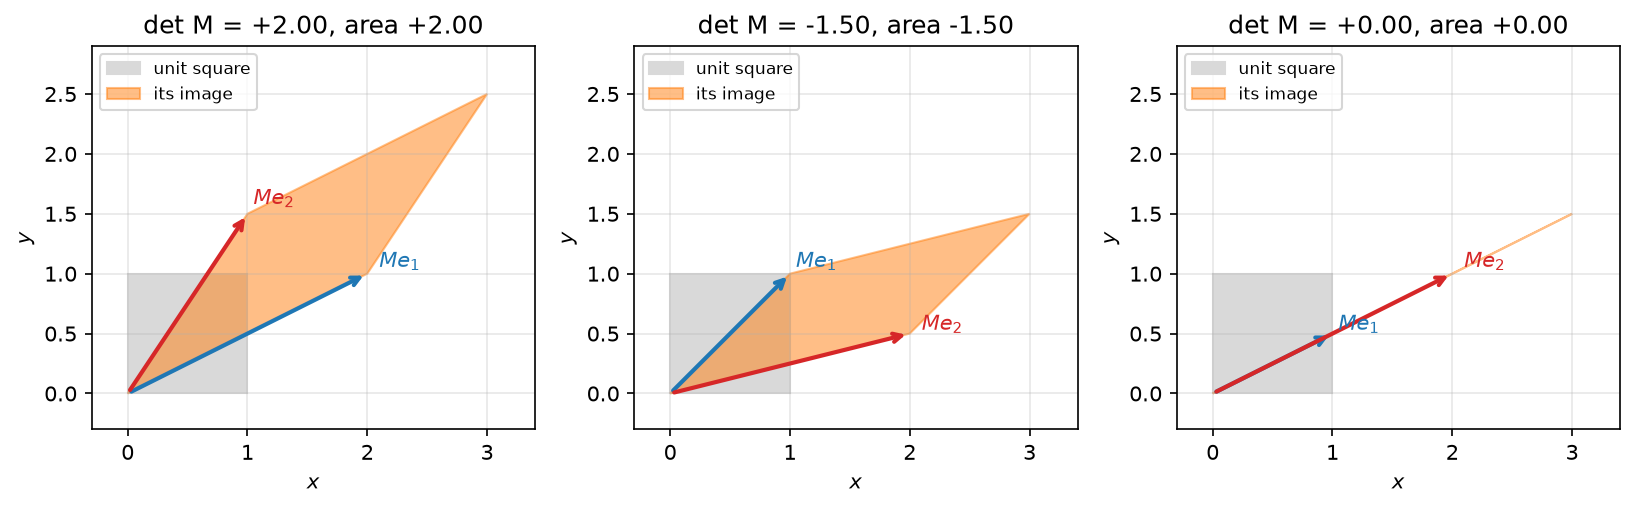

Figure 01a.3 saved as Revision/textbook/figures/01a_3_area_and_determinant.png
PASS the signed area of the image of the unit square is det M (3 examples and 1000 random
    matrices)


In [12]:
def signed_area(corners):
    """The shoelace formula: positive for corners listed counterclockwise."""
    total = 0.0
    for k in range(len(corners)):
        x1, y1 = corners[k]
        x2, y2 = corners[(k + 1) % len(corners)]  # % len: after the last, the first
        total += x1 * y2 - x2 * y1
    return total / 2


square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], dtype=float)  # counterclockwise
examples = [np.array([[2.0, 1.0], [1.0, 1.5]]),
            np.array([[1.0, 2.0], [1.0, 0.5]]),
            np.array([[1.0, 2.0], [0.5, 1.0]])]
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.9))
for ax, Mx in zip(axes, examples):
    image = square @ Mx.T  # each corner (a row) multiplied by the matrix
    ax.fill(square[:, 0], square[:, 1], color="0.85", label="unit square")
    ax.fill(image[:, 0], image[:, 1], color="tab:orange", alpha=0.5,
            label="its image")
    ax.annotate("", xy=Mx[:, 0], xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": "tab:blue", "lw": 2})
    ax.annotate("", xy=Mx[:, 1], xytext=(0, 0),
                arrowprops={"arrowstyle": "->", "color": "tab:red", "lw": 2})
    ax.text(*(Mx[:, 0] * 1.05), "$M e_1$", color="tab:blue")
    ax.text(*(Mx[:, 1] * 1.05), "$M e_2$", color="tab:red")
    ax.set_title(f"det M = {np.linalg.det(Mx):+.2f}, area {signed_area(image):+.2f}")
    ax.set_aspect("equal")
    ax.set_xlim(-0.3, 3.4)
    ax.set_ylim(-0.3, 2.9)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
save_figure(fig, "area_and_determinant",
            "The unit square (grey) and its image (orange) under three $2 \\times 2$ "
            "matrices $M$; horizontal axis $x$, vertical axis $y$ (pure numbers). The "
            "blue and red arrows are the columns $M e_1$ and $M e_2$. Left: "
            "$\\det M = 2$, the area doubles. Middle: $\\det M = -1.5$, the area is "
            "1.5 and the arrows have exchanged their order (the picture is "
            "mirrored). Right: $\\det M = 0$, the square is flattened onto a line "
            "and the matrix cannot be undone.")
areas_match = all(abs(signed_area(square @ Mx.T) - np.linalg.det(Mx)) < 1e-12
                  for Mx in examples)
random_matrices = generator.normal(size=(1000, 2, 2))  # 1000 random 2 x 2 matrices
areas_match &= all(abs(signed_area(square @ Mx.T) - np.linalg.det(Mx)) < 1e-12
                   for Mx in random_matrices)
check(areas_match, "the signed area of the image of the unit square is det M "
      "(3 examples and 1000 random matrices)")

## 11. Why computers do not use the Leibniz formula for big matrices

The Leibniz formula has $n!$ terms. Elimination (subtracting multiples of rows
until the matrix is triangular, which by rule 6 does not change the
determinant; then the determinant is the product of the diagonal) needs about
$n^3/3$ multiplications. The next cell prints and plots both numbers for
$n = 1$ to $16$. For the $16 \times 16$ gamma matrices of the theory the Leibniz
formula would have $16!$ = 20,922,789,888,000 terms. The vertical axis is
logarithmic: each step up multiplies by 10.

RESULT number of terms of the Leibniz formula for n = 16 = 20922789888000
PASS 16! = 20 922 789 888 000


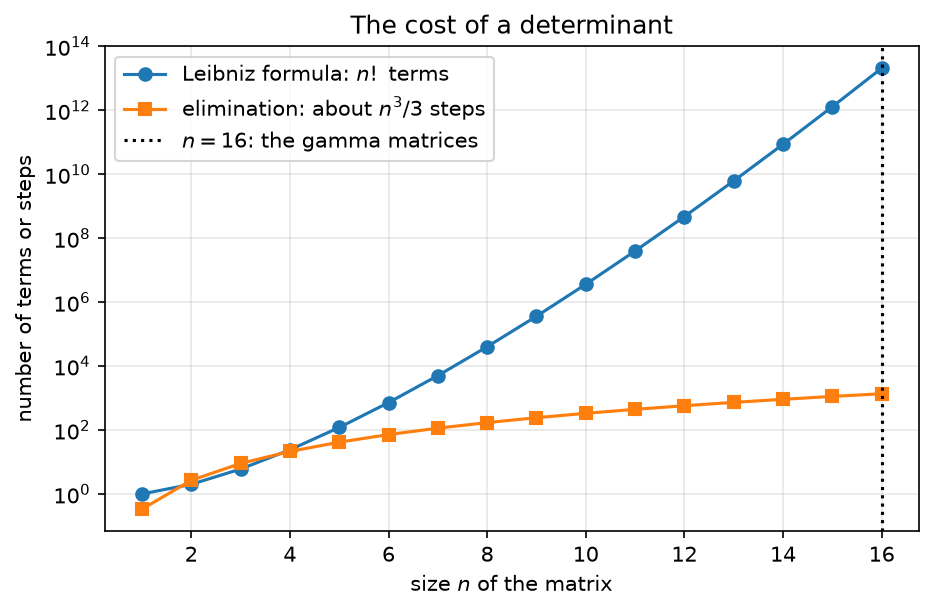

Figure 01a.4 saved as Revision/textbook/figures/01a_4_determinant_cost.png


In [13]:
sizes = np.arange(1, 17)
leibniz_terms = np.array([math.factorial(int(k)) for k in sizes], dtype=float)
elimination_steps = sizes.astype(float) ** 3 / 3
report("number of terms of the Leibniz formula for n = 16", math.factorial(16))
check(math.factorial(16) == 20922789888000, "16! = 20 922 789 888 000")
fig, ax = plt.subplots()
ax.semilogy(sizes, leibniz_terms, "o-", label="Leibniz formula: $n!$ terms")
ax.semilogy(sizes, elimination_steps, "s-", label="elimination: about $n^3/3$ steps")
ax.axvline(16, color="black", ls=":", label="$n = 16$: the gamma matrices")
ax.set_xlabel("size $n$ of the matrix")
ax.set_ylabel("number of terms or steps")
ax.set_title("The cost of a determinant")
ax.legend();
# The two counts for n = 16, rounded, for the caption: 2.1e13 and 1365.
mantissa, exponent = f"{leibniz_terms[-1]:.1e}".split("e")
save_figure(fig, "determinant_cost",
            "The number of terms $n!$ of the Leibniz formula (circles) and the "
            "number of steps $n^3/3$ of elimination (squares) for an $n \\times n$ "
            "matrix, $n = 1$ to $16$; horizontal axis $n$, vertical axis the count "
            "on a logarithmic scale. Up to $n = 4$ the two are similar; for "
            f"$n = 16$ the Leibniz formula has about ${mantissa} \\times "
            f"10^{{{int(exponent)}}}$ terms against about "
            f"{elimination_steps[-1]:.0f} steps of elimination.")

## 12. Matrices of the course: the gamma matrices of the Revision record

The file Revision/algebra/gammas.json of the Revision record holds the eight real
$16 \times 16$ gamma matrices $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$ of the
author's theory (one for each coordinate, rebuilt in the Revision record from the
author's formulas) and the diagonal of the frame metric $\eta$. The next cell
reads the file (a JSON file: text that holds lists and numbers) and checks what
the record states in its check
`reality_signed_permutations`: every entry is $-1$, $0$ or $1$, and every row and
every column has exactly one entry that is not zero. Such a *signed permutation
matrix* is a permutation matrix with some 1s replaced by $-1$.

In [14]:
record = json.loads(repository_file("Revision/algebra/gammas.json")
                    .read_text(encoding="utf-8"))
names = record["coordinates"]  # ["x1", "x2", ..., "x8"]
eta = record["eta"]  # the diagonal of the frame metric, in the order x1 ... x8
gamma = [np.array(matrix, dtype=int) for matrix in record["gamma"]]
say(f"coordinates: {names}")
say(f"diagonal of eta: {eta}")
signed_permutation = True
for g_a in gamma:
    signed_permutation &= set(np.unique(g_a).tolist()) <= {-1, 0, 1}
    signed_permutation &= ((g_a != 0).sum(axis=1) == 1).all()  # one per row
    signed_permutation &= ((g_a != 0).sum(axis=0) == 1).all()  # one per column
check(len(gamma) == 8 and all(g_a.shape == (16, 16) for g_a in gamma),
      "the record holds eight 16 x 16 gamma matrices")
check(signed_permutation, "every gamma matrix is a real signed permutation matrix",
      record="Revision/algebra/reports/python-algebra.json, "
             "check reality_signed_permutations")

coordinates: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
diagonal of eta: [1, 1, 1, -1, -1, -1, -1, 1]
PASS the record holds eight 16 x 16 gamma matrices
PASS every gamma matrix is a real signed permutation matrix
     reproduces Revision/algebra/reports/python-algebra.json, check
    reality_signed_permutations


For a signed permutation matrix only one term of the Leibniz formula is not zero:
the term of the permutation $\sigma$ whose entries $\gamma_{i\sigma(i)}$ are the
nonzero ones. So $\det \gamma = \mathrm{sign}(\sigma) \cdot s_1 s_2 \cdots s_{16}$,
where $s_i = \pm 1$ are the signs of these entries. This needs 16 numbers and one
permutation instead of $16!$ terms.

The next cell computes the determinant of each gamma matrix this way, compares it
with sympy's exact determinant and with numpy's, and checks that each gamma
matrix squared is $\eta_{aa}$ times the $16 \times 16$ identity matrix: $+I$ for
the space-like directions $x_1, x_2, x_3, x_8$ and $-I$ for the time-like
directions $x_4, \dots, x_7$ (this is the part with equal indices of the
relation $\gamma^a \gamma^b + \gamma^b \gamma^a = 2 \eta^{ab} I$ that the gamma
matrices obey).

In [15]:
identity16 = np.eye(16, dtype=int)  # the 16 x 16 identity matrix
all_det_one = True
squares_right = True
for name, eta_aa, g_a in zip(names, eta, gamma):
    order = [int(np.flatnonzero(row)[0]) for row in g_a]  # column of each nonzero
    signs = [int(g_a[i, order[i]]) for i in range(16)]  # the nonzero entries
    det_by_structure = sign(order) * math.prod(signs)
    det_exact = sp.Matrix(g_a.tolist()).det()
    det_numpy = np.linalg.det(g_a)
    say(f"gamma^({name}): eta {eta_aa:+d}, {signs.count(-1)} entries -1, "
        f"permutation sign {sign(order):+d}, det {det_by_structure:+d}, "
        f"sympy {det_exact}, numpy {det_numpy:.3f}")
    all_det_one &= det_by_structure == det_exact == 1 and abs(det_numpy - 1) < 1e-9
    squares_right &= (g_a @ g_a == eta_aa * identity16).all()
check(all_det_one, "every gamma matrix has determinant 1 (three ways)")
check(squares_right, "gamma^a gamma^a = eta_aa times the identity for every a",
      record="Revision/algebra/reports/python-algebra.json, check "
             "clifford_relation (its 8 relations with equal indices)")

gamma^(x1): eta +1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x2): eta +1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x3): eta +1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x4): eta -1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x5): eta -1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x6): eta -1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x7): eta -1, 8 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
gamma^(x8): eta +1, 0 entries -1, permutation sign +1, det +1, sympy 1, numpy 1.000
PASS every gamma matrix has determinant 1 (three ways)
PASS gamma^a gamma^a = eta_aa times the identity for every a
     reproduces Revision/algebra/reports/python-algebra.json, check clifford_relation
    (its 8 relations with equal indices)


The next cell draws $\gamma^{(x_1)}$ (a space-like direction), $\gamma^{(x_4)}$
(the time) and the product $\gamma^{(x_4)} \gamma^{(x_4)}$, which is $-I$: blue
squares on the diagonal and white elsewhere.

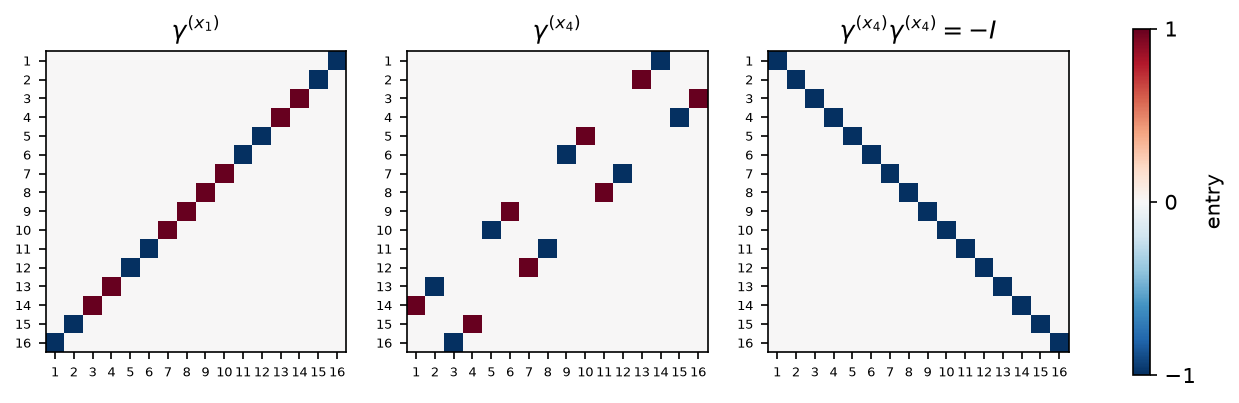

Figure 01a.5 saved as Revision/textbook/figures/01a_5_gamma_matrices.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
ticks = [str(k) for k in range(1, 17)]
pictures = [(gamma[0], "$\\gamma^{(x_1)}$"), (gamma[3], "$\\gamma^{(x_4)}$"),
            (gamma[3] @ gamma[3], "$\\gamma^{(x_4)} \\gamma^{(x_4)} = -I$")]
for ax, (matrix, title) in zip(axes, pictures):
    image = heat_map(ax, matrix, title, labels=ticks, annotate=False)
    ax.tick_params(labelsize=6)
fig.colorbar(image, ax=axes, shrink=0.75, label="entry", ticks=[-1, 0, 1])
save_figure(fig, "gamma_matrices",
            "Heat maps of two of the eight real $16 \\times 16$ gamma matrices of "
            "the Revision record, $\\gamma^{(x_1)}$ (left) and $\\gamma^{(x_4)}$ "
            "(middle), and of the product $\\gamma^{(x_4)}\\gamma^{(x_4)}$ (right); "
            "rows down and columns across numbered 1 to 16, red $+1$, blue $-1$, "
            "white 0. Every row and column of a gamma matrix has exactly one "
            "coloured square, and the square of the time-like $\\gamma^{(x_4)}$ is "
            "minus the identity matrix.")

## 13. The author's metric and its determinant

The file Revision/gkd_lovelock/results/curvature.json of the Revision record
stores the diagonal of the author's metric as text in the notation of the
program Mathematica, for example `E^(2*a4[x4])*Sin[6*H*x8]^(1/3)` for
$e^{2a_4(x_4)} \sin^{1/3}(6 H x_8)$, and the square root of the size of its
determinant as `Sin[6*H*x8]*Cot[6*H*x8]`.

The next cell types the metric exactly as in section 4 of this notebook, with
sympy symbols $a_4$ (the value of $a_4(x_4)$ at one time, any real number) and
$z = 6 H x_8$ (a positive number), translates the record's text into sympy (the
function `from_record` replaces the Mathematica names by sympy names), and checks:

- the record's diagonal equals the typed one, entry by entry;
- the product of the diagonal entries, $\det g$, simplifies to $\cos^2 z$ (no
  $a_4$ is left);
- the record's $\sin z \cot z$ equals $\cos z$, whose square is $\det g$.

In [17]:
a4 = sp.Symbol("a4", real=True)  # the value of the function a4(x4) at one time
z = sp.Symbol("z", positive=True)  # z = 6 H x8, between 0 and pi/2
s = sp.sin(z) ** sp.Rational(1, 3)  # sin(z) to the power 1/3
g_typed = ([sp.exp(2 * a4) * s] * 3 + [sp.Integer(-1)]
           + [-sp.exp(-2 * a4) * s] * 3 + [sp.cot(z) ** 2])
curvature = json.loads(repository_file("Revision/gkd_lovelock/results/curvature.json")
                       .read_text(encoding="utf-8"))


def from_record(text):
    """The record's Mathematica text as a sympy expression."""
    text = text.replace("a4[x4]", "a4").replace("Sin[6*H*x8]", "sin(z)")
    text = text.replace("Cot[6*H*x8]", "cot(z)").replace("^", "**")
    return sp.sympify(text, locals={"a4": a4, "z": z, "E": sp.E})


g_record = [from_record(text) for text in curvature["metricDiagonal"]]
check(all(sp.simplify(x - y) == 0 for x, y in zip(g_record, g_typed)),
      "the record's metric diagonal equals the author's metric typed here")
det_g = sp.Mul(*g_typed)  # the product of the 8 diagonal entries
say(f"product of the diagonal entries, as sympy writes it: {det_g}")
check(sp.simplify(det_g - sp.cos(z) ** 2) == 0,
      "det g = cos(z)^2 for every a4: the e^(6 a4) of space and the e^(-6 a4) of "
      "the extra times cancel",
      record="Revision/gkd_lovelock/results/python-lovelock-report.json, check "
             "sqrt_abs_det_g")
root_record = from_record(curvature["sqrtAbsDetG"])
say(f"the record's square root of |det g|: {root_record}")
check(sp.simplify(root_record - sp.cos(z)) == 0 and
      sp.simplify(root_record ** 2 - det_g) == 0,
      "the record's sqrtAbsDetG = sin z cot z = cos z, and its square is det g",
      record="Revision/gkd_lovelock/results/curvature.json, sqrtAbsDetG")

PASS the record's metric diagonal equals the author's metric typed here
product of the diagonal entries, as sympy writes it: sin(z)**2*cot(z)**2
PASS det g = cos(z)^2 for every a4: the e^(6 a4) of space and the e^(-6 a4) of the extra
    times cancel
     reproduces Revision/gkd_lovelock/results/python-lovelock-report.json, check
    sqrt_abs_det_g
the record's square root of |det g|: sin(z)*cot(z)
PASS the record's sqrtAbsDetG = sin z cot z = cos z, and its square is det g
     reproduces Revision/gkd_lovelock/results/curvature.json, sqrtAbsDetG


The next cell turns the exact formulas into numbers (sympy's `lambdify` makes a
numpy function of a formula) and draws two pictures. Left: the heat map of the
$8 \times 8$ metric at $a_4 = 0.5$, $z = 0.9$, with the coordinate names on the
axes; only the diagonal is coloured. Right: $\det g$ computed with numpy from the
$8 \times 8$ matrix for $a_4 = -1$, $0$ and $1$ along $0 < z < \pi/2$, together
with $\cos^2 z$: the three curves lie on top of each other. It also checks the
agreement in numbers at 300 values of $z$.

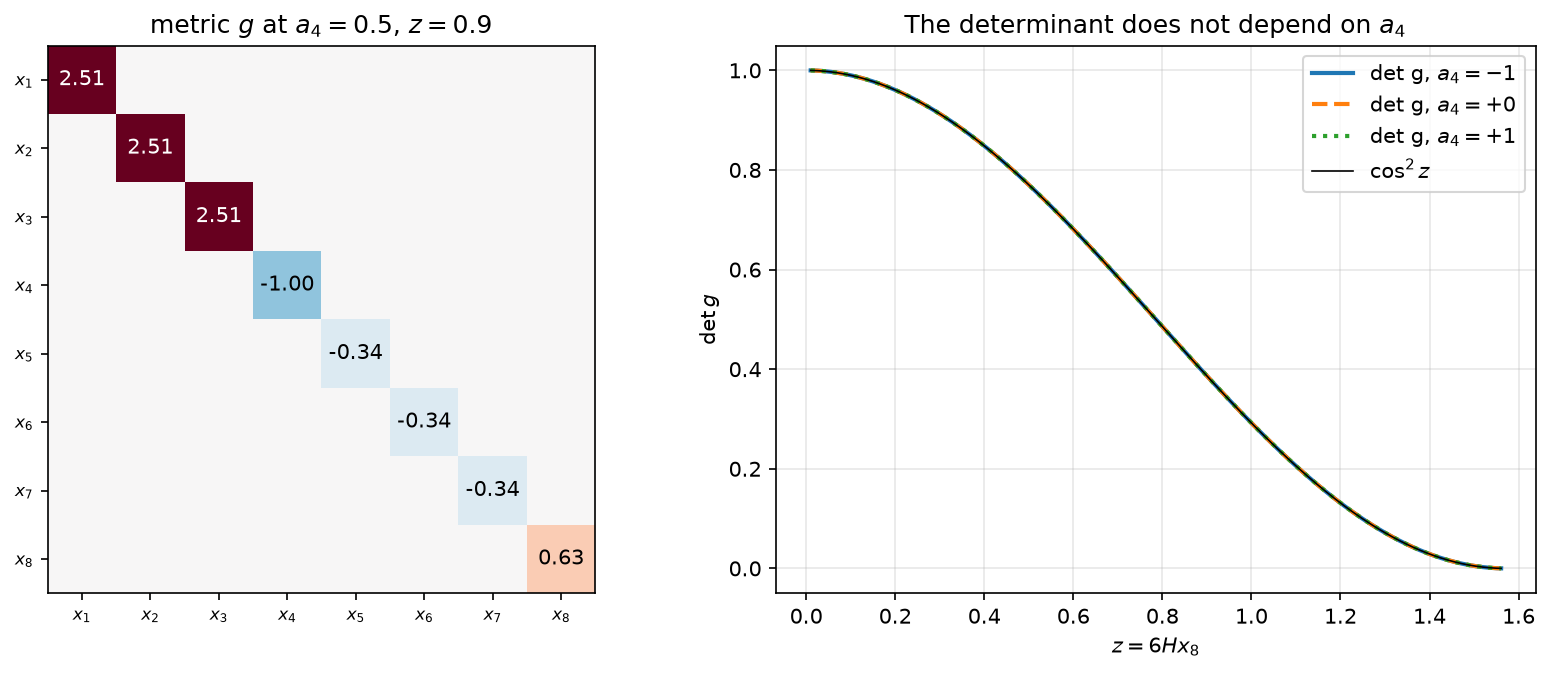

Figure 01a.6 saved as Revision/textbook/figures/01a_6_metric_and_determinant.png
RESULT largest difference between det g and cos(z)^2 at 900 points = 3.1e-15
PASS numpy: det g = cos(z)^2 at 300 values of z for each of a4 = -1, 0, 1


In [18]:
metric_numbers = sp.lambdify((a4, z), g_typed, "numpy")  # a4, z -> 8 numbers
z_values = np.linspace(0.01, np.pi / 2 - 0.01, 300)  # inside (0, pi/2)
fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.6))
g_point = np.diag(np.array(metric_numbers(0.5, 0.9), dtype=float))
coordinate_labels = [f"$x_{k}$" for k in range(1, 9)]  # x with subscripts 1 ... 8
heat_map(left, g_point, "metric $g$ at $a_4 = 0.5$, $z = 0.9$",
         labels=coordinate_labels, digits=2, skip_zeros=True)
left.tick_params(labelsize=8)
largest_error = 0.0
for a4_value, style in [(-1.0, "-"), (0.0, "--"), (1.0, ":")]:
    dets = np.array([np.linalg.det(np.diag(np.array(metric_numbers(a4_value, zv),
                                                    dtype=float)))
                     for zv in z_values])
    largest_error = max(largest_error, float(np.max(np.abs(dets - np.cos(z_values)
                                                           ** 2))))
    right.plot(z_values, dets, style, lw=2, label=f"det g, $a_4 = {a4_value:+.0f}$")
right.plot(z_values, np.cos(z_values) ** 2, color="black", lw=0.8,
           label="$\\cos^2 z$")
right.set_xlabel("$z = 6 H x_8$")
right.set_ylabel("$\\det g$")
right.set_title("The determinant does not depend on $a_4$")
right.legend()
fig.tight_layout()
save_figure(fig, "metric_and_determinant",
            "Left: heat map of the author's $8 \\times 8$ metric at $a_4 = 0.5$ and "
            "$z = 6 H x_8 = 0.9$, rows and columns labelled by the coordinates "
            "$x_1$ to $x_8$; only the diagonal is not zero (the plain white "
            "squares are zeros), positive for $x_1, x_2, x_3, x_8$ and negative "
            "for $x_4$ to $x_7$. Right: the "
            "determinant of the metric computed numerically for $a_4 = -1$, 0 and "
            "1 (three line styles) against $z$ from 0 to $\\pi/2$, and "
            "$\\cos^2 z$ (thin black line); horizontal axis $z$, vertical axis "
            "$\\det g$ (pure numbers). All curves coincide: the inflation of space "
            "and the deflation of the extra times cancel in the determinant.")
report("largest difference between det g and cos(z)^2 at 900 points",
       f"{largest_error:.1e}")
check(largest_error < 1e-12, "numpy: det g = cos(z)^2 at 300 values of z for "
      "each of a4 = -1, 0, 1")

## 14. The last check

The last cell checks that the six figure files of this notebook exist in the
folder Revision/textbook/figures and prints the number of checks that passed.

In [19]:
figure_names = ["01a_1_matrix_product.png", "01a_2_permutation_matrices.png",
                "01a_3_area_and_determinant.png", "01a_4_determinant_cost.png",
                "01a_5_gamma_matrices.png", "01a_6_metric_and_determinant.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in figure_names),
      "all 6 figure files of this notebook exist")
all_checks_passed()

PASS all 6 figure files of this notebook exist
ALL 30 CHECKS PASSED (notebook 01a)


## 15. What this notebook showed

- A matrix product $(AB)_{ik} = A_{ij} B_{jk}$ (summation convention: $j$ is
  summed) can be computed with loops, with `einsum` or with `@`; the three agree,
  and $AB \neq BA$ in general, while $(AB)^T = B^T A^T$ and the traces of $AB$
  and $BA$ are equal.
- A permutation of $n$ objects has a sign $\pm 1$ given by its number of
  inversions; half of the $n!$ permutations are even ($n \geq 2$), and
  exchanging two entries flips the sign.
- The Leibniz formula, written by hand, gives the same determinants as sympy and
  numpy; determinants obey the six rules of section 9 and measure signed areas.
  For big matrices the Leibniz formula is far too long ($16! \approx 2 \times
  10^{13}$ terms), but for a signed permutation matrix only one term survives.
- The eight gamma matrices of the Revision record are real signed permutation
  matrices with determinant 1; each squares to $+I$ (space-like directions
  $x_1, x_2, x_3, x_8$) or $-I$ (time-like directions $x_4, \dots, x_7$).
- The determinant of the author's metric is $\det g = \cos^2(6 H x_8)$ for every
  value of $a_4$: the growth $e^{6a_4}$ of the three space directions and the
  shrinking $e^{-6a_4}$ of the three extra times cancel exactly. This repeats the
  Revision record's check `sqrt_abs_det_g`.